# Detecting Fraudulent Mobile-Money Transactions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CS-Shahad/Fraud_Detection_Model/blob/main/notebooks/fraud_detection.ipynb)

**Goal:** flag fraudulent transactions in the [PaySim](https://www.kaggle.com/datasets/ealtaf/paysim1) dataset,
a simulation of 6.3 million mobile-money transactions built from real logs of a mobile-money service.

**Why it's hard:** only about 0.13% of transactions are fraud. A model that calls everything legitimate is
99.87% accurate and completely useless, so this notebook judges models on **precision, recall and PR-AUC
for the fraud class**, not on accuracy.

**Result:** on a held-out test set of 554,082 transactions, the best model (XGBoost) catches **1,634 of
1,643 frauds (99.5%)** and **99.9% of the stolen money**, with **zero false alarms**. The rule already in
the data (`isFlaggedFraud`) catches 3.

**Contents**
1. Setup
2. Load the data
3. Exploratory analysis
4. Feature engineering
5. Train / validation / test split
6. Model training and comparison
7. Results on the test set
8. What drives the model
9. Save the model
10. Conclusions and next steps

## 1. Setup

The reusable code (feature engineering, models, metrics, charts) lives in the `src/fraud_detection` package
so the notebook and the command-line training script share exactly the same logic.
When run in Google Colab, the cell below clones the repository and installs it.

In [1]:
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/CS-Shahad/Fraud_Detection_Model.git
    %cd Fraud_Detection_Model
    !pip install -q -e .
    sys.path.insert(0, "src")

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display

from fraud_detection import plots
from fraud_detection.config import FIGURES_DIR, TARGET
from fraud_detection.data import find_data_file, load_transactions
from fraud_detection.evaluation import classification_metrics, comparison_table
from fraud_detection.features import FEATURES, FRAUD_PRONE_TYPES, add_features, filter_fraud_prone
from fraud_detection.train import best_tree_model_name, feature_importances, save_outputs, train_and_evaluate

pd.set_option("display.float_format", "{:,.4f}".format)
plots.apply_style()

## 2. Load the data

`find_data_file` uses the CSV (or Kaggle's zip) in `data/` if there is one. Otherwise it downloads the
dataset from Kaggle, which needs a Kaggle API token. To use a copy in Google Drive instead, mount the drive
and set `DATA_PATH` to the file.

In [3]:
DATA_PATH = None  # e.g. "/content/drive/MyDrive/Fraud_data/PS_20174392719_1491204439457_log.csv"

df = load_transactions(find_data_file(DATA_PATH))
print(f"{len(df):,} rows x {df.shape[1]} columns")
df.head()

6,362,620 rows x 9 columns


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6400","170,136.0000","160,296.3600",0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800","21,249.0000","19,384.7200",0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,181.0000,0.0000,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,181.0000,0.0000,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400","41,554.0000","29,885.8600",0.0000,0.0000,0,0


| Column | Meaning |
|---|---|
| `step` | Hour since the start of the simulation (1 to 743, about 31 days) |
| `type` | PAYMENT, TRANSFER, CASH_OUT, DEBIT or CASH_IN |
| `amount` | Transaction amount |
| `nameOrig` / `nameDest` | Sender and receiver IDs |
| `oldbalanceOrg` / `newbalanceOrig` | Sender balance before and after |
| `oldbalanceDest` / `newbalanceDest` | Receiver balance before and after |
| `isFraud` | **Target:** 1 if the transaction is fraudulent |
| `isFlaggedFraud` | Output of the existing rule: flags transfers above 200,000 |

In [4]:
print("Missing values:", int(df.isna().sum().sum()))
counts = df[TARGET].value_counts()
print(f"Fraudulent: {counts[1]:,} ({counts[1] / len(df):.3%})")
print(f"Legitimate: {counts[0]:,}")

Missing values: 0
Fraudulent: 8,213 (0.129%)
Legitimate: 6,354,407


## 3. Exploratory analysis

### Which transaction types carry fraud?

isFraud,legitimate,fraud,All
type,,,
CASH_IN,1399284,0,1399284
CASH_OUT,2233384,4116,2237500
DEBIT,41432,0,41432
PAYMENT,2151495,0,2151495
TRANSFER,528812,4097,532909
All,6354407,8213,6362620


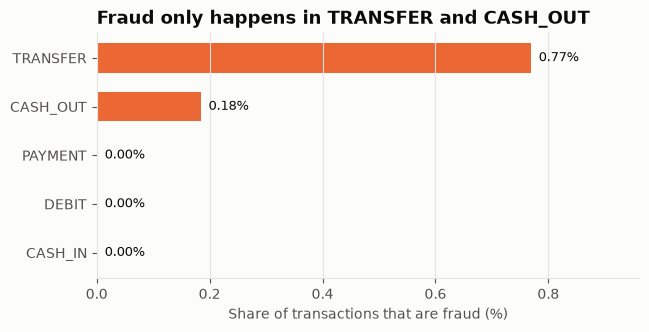

In [5]:
display(pd.crosstab(df["type"], df[TARGET], margins=True).rename(columns={0: "legitimate", 1: "fraud"}))
plots.fraud_rate_by_type(df, path=FIGURES_DIR / "fraud_rate_by_type.png");

Every fraudulent transaction is a **TRANSFER** or a **CASH_OUT**. That matches the fraud pattern the
simulator models: take over an account, transfer the money to a mule account, then cash it out.
PAYMENT, DEBIT and CASH_IN can therefore be marked legitimate by rule, which removes over half the rows
before modelling.

### Do fraudulent amounts look different?

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"2,762,196.0000","314,115.4962","877,144.1496",0.0100,"82,908.2325","171,034.4600","305,994.1850","92,445,516.6400"
1,"8,213.0000","1,467,967.2991","2,404,252.9472",0.0000,"127,091.3300","441,423.4400","1,517,771.4800","10,000,000.0000"


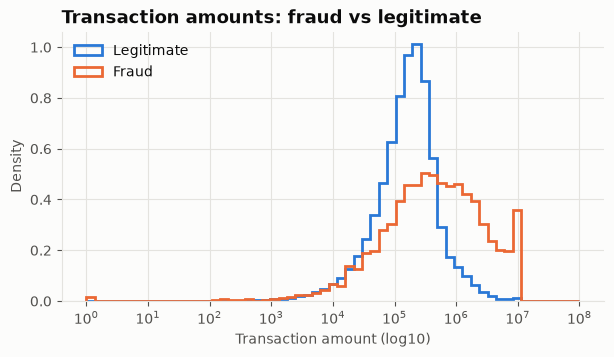

In [6]:
prone = filter_fraud_prone(df)
plots.amount_distribution(prone, path=FIGURES_DIR / "amount_distribution.png");
prone.groupby(TARGET)["amount"].describe()

Fraudulent transactions are larger: the median fraud moves about **441k**, against about **171k** for a
legitimate TRANSFER or CASH_OUT. Fraud amounts also stop sharply at **10 million**, which looks like a
per-transaction cap in the simulator.

### When does fraud happen?

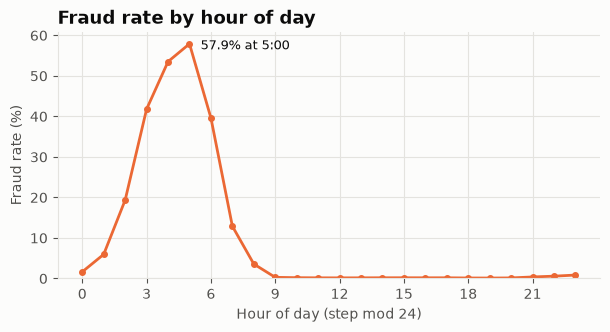

In [7]:
plots.fraud_rate_by_hour(prone, path=FIGURES_DIR / "fraud_rate_by_hour.png");

Between 3:00 and 6:00, **roughly 40% to 58%** of transactions are fraud, compared with almost none during the
day: fraud carries on at night, when there is little legitimate activity. The hour of day
(`step % 24`) is therefore kept as a feature.

### How good is the existing rule?

In [8]:
rule = classification_metrics(df[TARGET], df["isFlaggedFraud"], threshold=0.5)
print(f"isFlaggedFraud flags {df['isFlaggedFraud'].sum()} transactions")
print(f"precision {rule['precision']:.2%}, recall {rule['recall']:.2%}")

isFlaggedFraud flags 16 transactions
precision 100.00%, recall 0.19%


The current rule is precise but catches only a tiny fraction of fraud. It is the baseline the models need
to beat. It is not used as a feature.

## 4. Feature engineering

The most telling signal in this data is whether an account's balances **add up**. For a legitimate
transfer, the sender's balance falls by the amount and the receiver's balance rises by it. Fraudulent
transactions often break this, for example money arrives but the receiver still shows a zero balance.

| Feature | Definition |
|---|---|
| `errorBalanceOrig` | `newbalanceOrig + amount - oldbalanceOrg` |
| `errorBalanceDest` | `oldbalanceDest + amount - newbalanceDest` |
| `origEmptied` | Sender had money and was left with exactly 0 |
| `destBalancesZero` | Receiver's balance is 0 before and after a non-zero transaction |
| `isTransfer` | TRANSFER (1) or CASH_OUT (0) |
| `hourOfDay` | `step % 24` |

The account IDs are dropped: almost every ID appears only once, so they can't generalise.

In [9]:
featured = add_features(prone)
featured.groupby(TARGET)[["origEmptied", "destBalancesZero"]].mean().rename(index={0: "legitimate", 1: "fraud"})

,origEmptied,destBalancesZero
isFraud,,
legitimate,0.4272,0.0006
fraud,0.9755,0.4956


## 5. Train / validation / test split

The data is split **60 / 20 / 20** with stratification, so each part keeps the same fraud rate:

- **train**: fit the models
- **validation**: pick each model's decision threshold and choose the best model
- **test**: touched once, at the end, for the final numbers

Choosing thresholds on the test set would make the reported results look better than they would be on new
data.

`train_and_evaluate` does the split, fits each model, tunes its threshold on validation (the cut-off that
maximises F1), and scores the test set.

## 6. Model training and comparison

Four models, from simple to strong:

- **Logistic Regression**: a linear baseline, with log-scaled inputs and balanced class weights
- **Random Forest**: an ensemble of decision trees
- **XGBoost** and **LightGBM**: gradient-boosted trees, usually the strongest choice for tabular data

Instead of oversampling, class imbalance is handled by **tuning the decision threshold** on the validation
set. This keeps the predicted probabilities meaningful.

In [10]:
result = train_and_evaluate(df)

Logistic Regression  PR-AUC 0.8772  precision 0.8175  recall 0.9921  (5s)
Random Forest        PR-AUC 0.9974  precision 0.9994  recall 0.9970  (222s)
XGBoost              PR-AUC 0.9978  precision 1.0000  recall 0.9945  (25s)
LightGBM             PR-AUC 0.9240  precision 0.9453  recall 0.9775  (38s)


## 7. Results on the test set

In [11]:
all_metrics = {"Rule baseline (isFlaggedFraud)": result.baseline_metrics, **result.test_metrics}
table = comparison_table(all_metrics)
table.style.format(
    {c: "{:.4f}" for c in ["pr_auc", "roc_auc", "precision", "recall", "f1"]}
    | {"fraud_amount_caught": "{:.2%}", "fp": "{:,}", "fn": "{:,}"}
)

,pr_auc,roc_auc,precision,recall,f1,fraud_amount_caught,fp,fn
XGBoost,0.9978,0.9987,1.0000,0.9945,0.9973,99.86%,0,9
Random Forest,0.9974,0.9988,0.9994,0.9970,0.9982,99.94%,1,5
LightGBM,0.9240,0.9883,0.9453,0.9775,0.9611,98.57%,93,37
Logistic Regression,0.8772,0.9983,0.8175,0.9921,0.8963,99.51%,364,13
Rule baseline (isFlaggedFraud),0.0048,0.5009,1.0000,0.0018,0.0036,0.48%,0,"1,640"


- **PR-AUC**: area under the precision-recall curve. It summarises performance across all thresholds and,
  unlike ROC-AUC, is not inflated by the huge number of easy legitimate transactions.
- **precision**: of the transactions flagged, the share that really are fraud (a low value means more
  customers get blocked for nothing).
- **recall**: of all fraud, the share that is caught.
- **fraud_amount_caught**: the share of stolen money in the test set that the model would have stopped.
- **fp / fn**: false alarms and missed frauds.

XGBoost and Random Forest are almost perfect and practically tied. XGBoost has the higher validation PR-AUC,
so it is the model that gets saved. Logistic regression still catches over 99% of fraud, but it needs
hundreds of false alarms to do it. LightGBM's validation threshold landed at 1.0: with these settings it
gives many transactions a score of exactly 1, so it cannot rank them finely. Tuning it is left as a next
step.

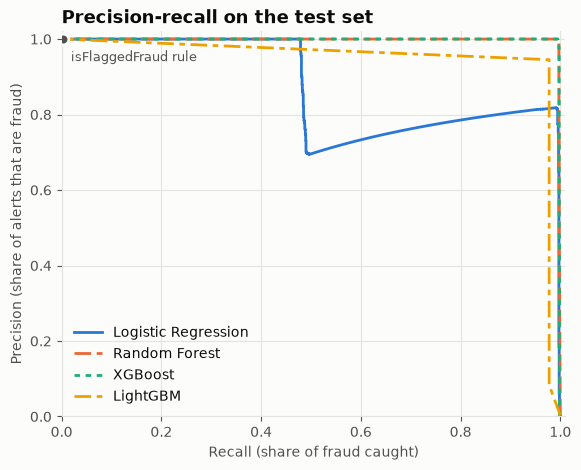

In [12]:
b = result.baseline_metrics
plots.precision_recall_curves(
    result.y_test, result.test_probas, baseline=(b["recall"], b["precision"], "isFlaggedFraud rule")
);

Best model on validation PR-AUC: XGBoost (threshold 0.806)


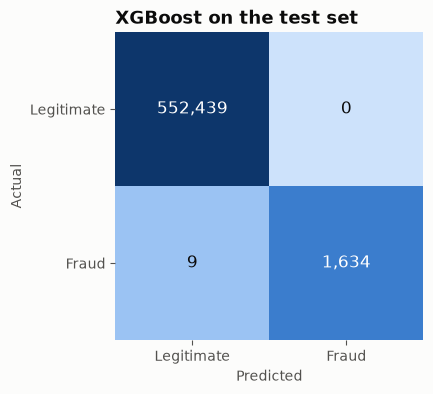

In [13]:
best = result.best_model_name
print(f"Best model on validation PR-AUC: {best} (threshold {result.thresholds[best]:.3f})")
plots.confusion_matrix_plot(result.test_metrics[best], f"{best} on the test set");

## 8. What drives the model

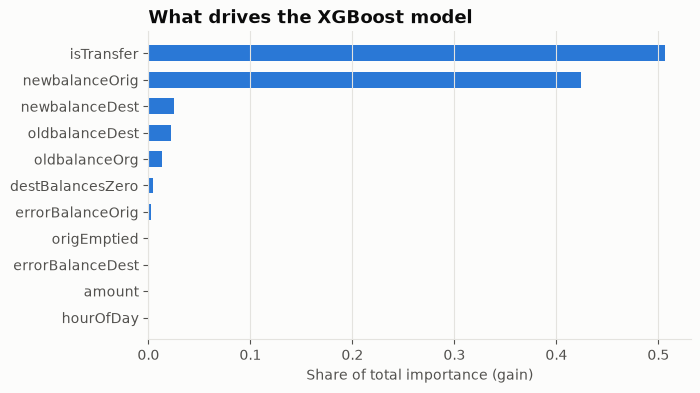

In [14]:
name = best_tree_model_name(result)
plots.feature_importance(feature_importances(result.models[name]), f"What drives the {name} model");

XGBoost relies mostly on two inputs: the **transaction type** and the **sender's balance after the
transaction** (fraud typically leaves the sender's account at zero). The engineered balance-error features
get little weight. That doesn't mean the pattern is irrelevant: a tree model can learn the same splits
straight from the raw balances, so the engineered versions add little on top of them.

Gain importance shows what the model uses, not what causes fraud, and it favours features that split early.

## 9. Save the model

`save_outputs` writes:

- `models/fraud_model.joblib`: the best model, its threshold and its feature list
- `reports/metrics.json` and `reports/model_comparison.md`: the test results
- `reports/figures/`: the charts used in the README

`fraud_detection.predict.FraudScorer` loads the model and scores new transactions.

,type,amount,isFraud,fraud_probability,is_fraud_alert
4644207,CASH_IN,"607,193.6400",0,0.0000,False
3800666,PAYMENT,"3,473.7500",0,0.0000,False
4426240,CASH_OUT,"66,170.6900",0,0.0000,False
5788765,TRANSFER,"335,384.2600",0,0.0000,False
2010701,CASH_IN,"234,392.2500",0,0.0000,False


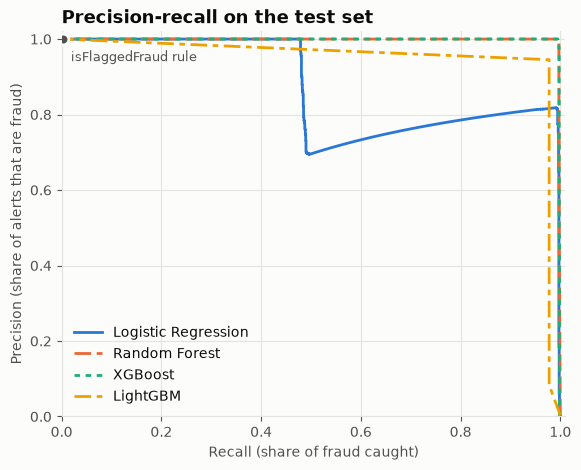

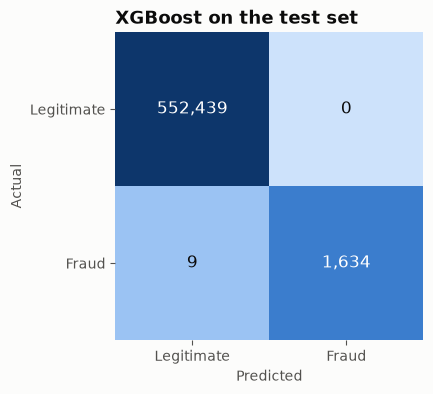

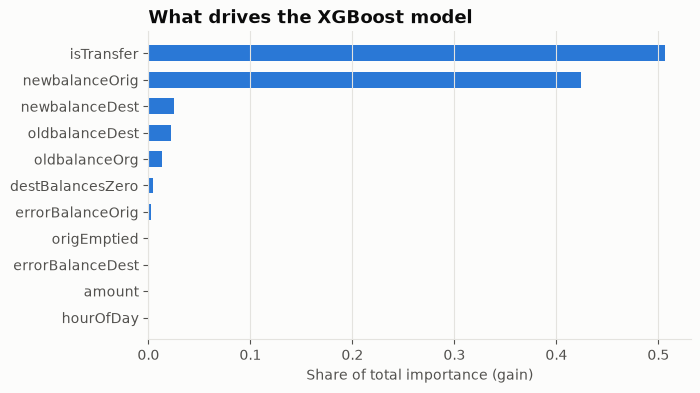

In [15]:
save_outputs(result)

from fraud_detection.predict import FraudScorer

scorer = FraudScorer()
sample = df.sample(5, random_state=0)
pd.concat([sample[["type", "amount", TARGET]], scorer.score(sample)], axis=1)

## 10. Conclusions and next steps

**Conclusions**

- Fraud in PaySim is confined to TRANSFER and CASH_OUT, and the clearest signal is what happens to the
  balances: fraud drains the sender's account.
- XGBoost and Random Forest detect over 99% of fraud with almost no false alarms, far ahead of logistic
  regression and of the existing `isFlaggedFraud` rule, which catches only 0.2% of fraud.
- Choosing the threshold on a validation set, rather than using the default 0.5, controls the trade-off
  between missed fraud and false alarms.

**Limitations**

- PaySim is simulated. The near-perfect scores come largely from how the simulator records balances for
  fraud, and real data is unlikely to separate this cleanly.
- The balances *after* a transaction are only known once it is processed, so this setup detects fraud
  just after the fact, not before authorisation.

**Next steps**

- Tune LightGBM, and measure how much each engineered feature adds by retraining without it.
- Validate on a time-based split (train on early days, test on later ones) to measure drift.
- Pick the threshold from a cost model (the cost of a missed fraud versus a false alarm) instead of F1.
- Add per-account behaviour features (for example transaction velocity) and explain individual
  predictions with SHAP.
- Serve `FraudScorer` behind a small REST API.